In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model  import LinearRegression
from sklearn import metrics

In [ ]:
insurance_dataset=pd.read_csv('/content/medical_insurance.csv')

In [ ]:
insurance_dataset.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance_dataset.shape

(2772, 7)

In [ ]:
insurance_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [ ]:
insurance_dataset.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
insurance_dataset.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


<ipython-input-18-74c40a86168c>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['age'])


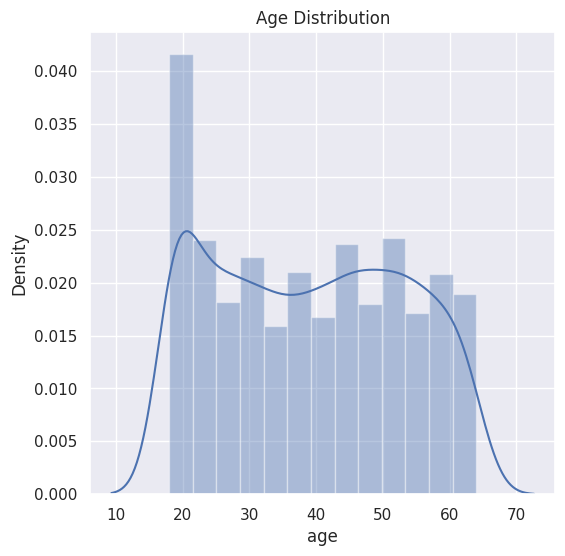

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['age'])
plt.title("Age Distribution")
plt.show()

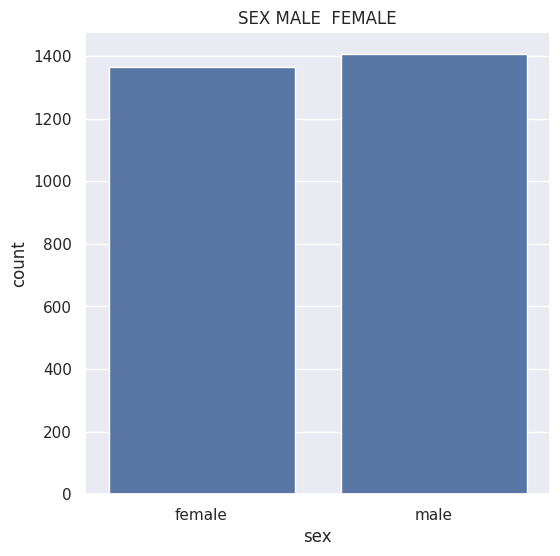

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data=insurance_dataset)
plt.title("SEX MALE  FEMALE")
plt.show()

<ipython-input-24-1fbae10f91f9>:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_dataset['bmi'])


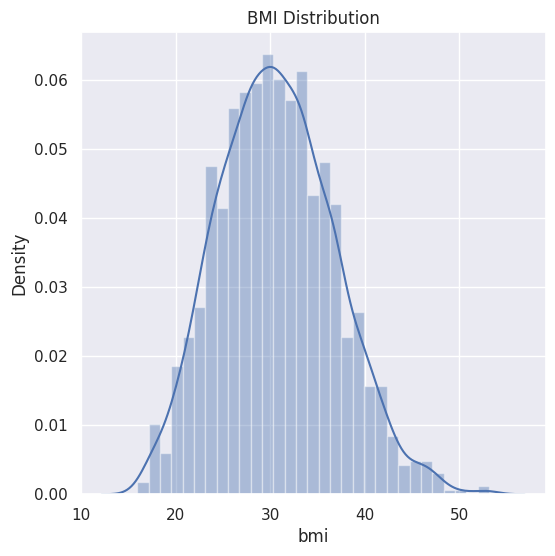

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_dataset['bmi'])
plt.title("BMI Distribution")
plt.show()

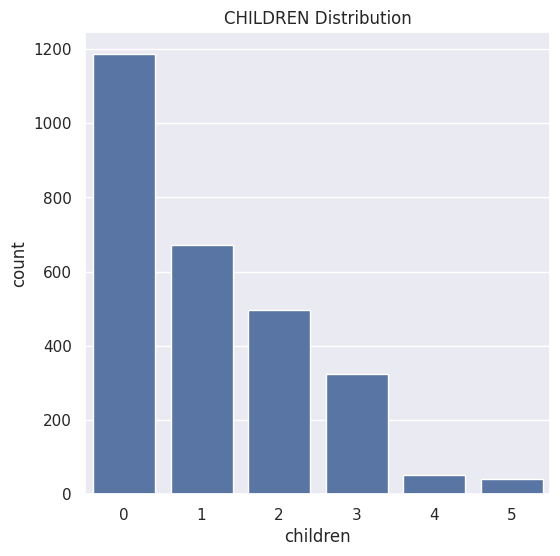

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_dataset)
plt.title("CHILDREN Distribution")
plt.show()

In [ ]:
insurance_dataset['children'].value_counts()


0    1186
1     672
2     496
3     324
4      52
5      42
Name: children, dtype: int64

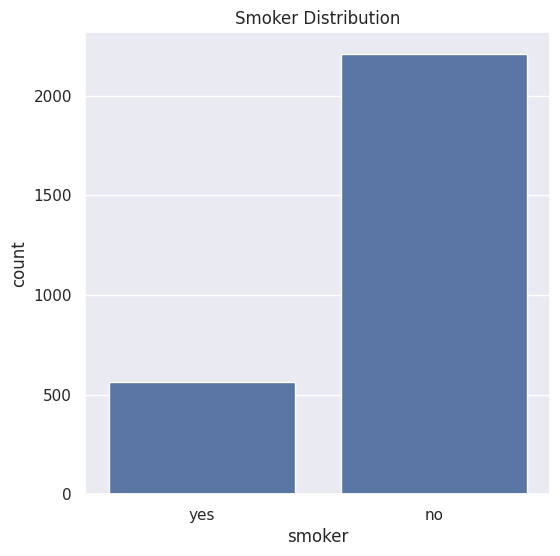

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=insurance_dataset)
plt.title("Smoker Distribution")
plt.show()

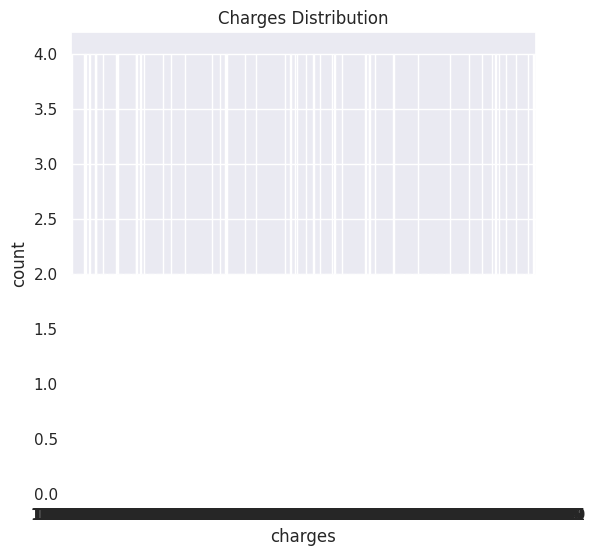

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x='charges',data=insurance_dataset)
plt.title("Charges Distribution")
plt.show()

In [ ]:
insurance_dataset['charges'].value_counts()

8798.59300     4
8569.86180     4
1633.96180     4
37607.52770    4
32108.66282    4
              ..
7512.26700     2
4762.32900     2
5910.94400     2
11454.02150    2
29141.36030    2
Name: charges, Length: 1337, dtype: int64

In [ ]:
insurance_dataset

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


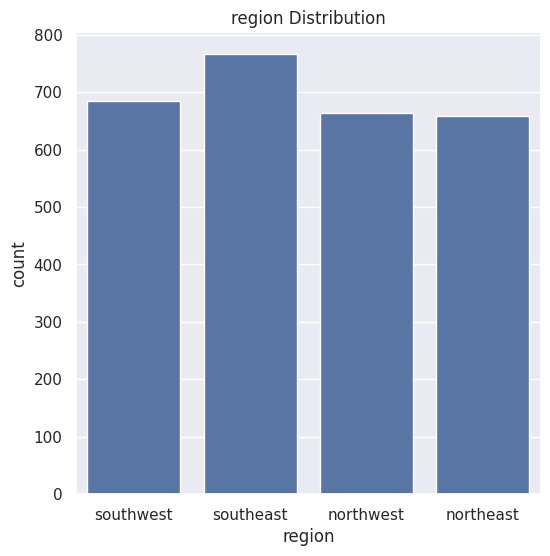

In [ ]:
sns.set()
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_dataset)
plt.title("region Distribution")
plt.show()

In [ ]:
insurance_dataset['region'].value_counts()

southeast    766
southwest    684
northwest    664
northeast    658
Name: region, dtype: int64

In [ ]:
 #encoding the categorical feautures
 insurance_dataset.replace({'sex':{'male':0,'female':1}},inplace=True)

In [ ]:
#encoding smoker column
insurance_dataset.replace({'smoker':{'yes':0,'no':1}},inplace=True)

In [ ]:
insurance_dataset.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)

In [ ]:
X=insurance_dataset.drop(['charges'],axis=1)

In [ ]:
Y=insurance_dataset['charges']

In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=2)
print(X.shape,X_train.shape,X_test.shape)

(2772, 6) (2217, 6) (555, 6)


In [ ]:
regressor=LinearRegression()
regressor.fit(X_train,Y_train)

LinearRegression()

In [ ]:
training_data_prediction=regressor.predict(X_train)
r2_train=metrics.r2_score(Y_train,training_data_prediction)
print("Accuracy score for training data:",r2_train)

Accuracy score for training data: 0.7561940076387632


In [ ]:
testing_data_prediction=regressor.predict(X_test)
r2_test=metrics.r2_score(Y_test,testing_data_prediction)
print("Accuracy_score on tesing data:",r2_test)

Accuracy_score on tesing data: 0.7272408044903713


In [ ]:
#Building a predictive system
input_data=(19,1,27.9,0,0,1)
input_data_as_numpy_array=np.asarray(input_data)
input_data_reshape=input_data_as_numpy_array.reshape(1,-1)

In [ ]:
#predicting the cost
prediction=regressor.predict(input_data_reshape)
print("THE PREDICTION COST IS:",prediction)

THE PREDICTION COST IS: [25035.53281243]


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
